✅ Hoàn tất. Dữ liệu đã được lưu E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f/


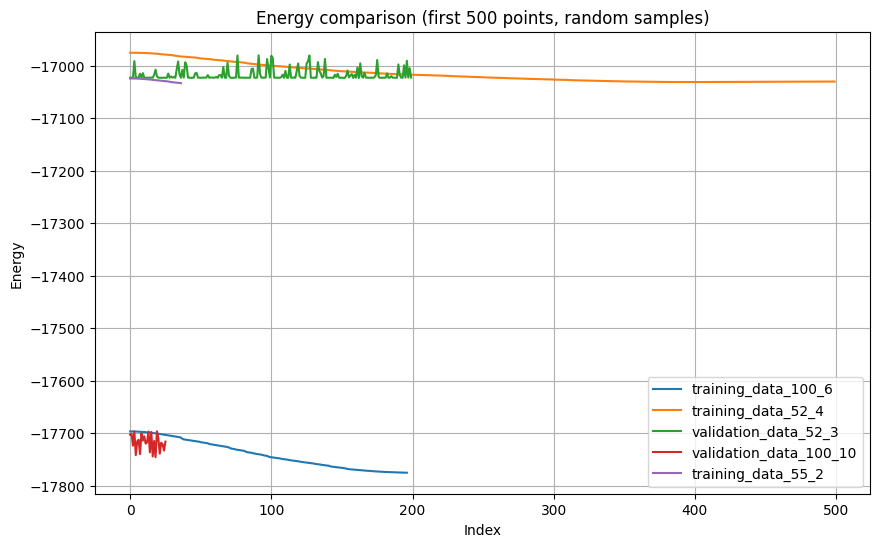

In [1]:

import os
import numpy as np

# Thư mục gốc chứa dữ liệu ban đầu
input_root = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100"
# Thư mục gốc chứa dữ liệu sau khi cắt
output_root = r"E:\Work Spaces\Thesis\Data\SiCH_v2\output_52_55_58_100_cut_500f"

os.makedirs(output_root, exist_ok=True)

# Duyệt qua tất cả thư mục con trong output/
for subdir in os.listdir(input_root):
    input_subdir = os.path.join(input_root, subdir, "set.000")
    if not os.path.isdir(input_subdir):
        continue  # bỏ qua nếu không phải thư mục hợp lệ
    
    # Tạo đường dẫn output tương ứng
    output_subdir = os.path.join(output_root, subdir, "set.000")
    os.makedirs(output_subdir, exist_ok=True)

    # Các file cần xử lý
    files = ["box.npy", "coord.npy", "energy.npy", "force.npy", "virial.npy"]

    for fname in files:
        input_file = os.path.join(input_subdir, fname)
        output_file = os.path.join(output_subdir, fname)

        if not os.path.exists(input_file):
            print(f"⚠️ File không tồn tại: {input_file}")
            continue

        # Load dữ liệu
        data = np.load(input_file)

        # Nếu có ít hơn 500 phần tử thì giữ nguyên
        if len(data) < 500:
            data_cut = data
        else:
            data_cut = data[:500]

        # Lưu lại
        np.save(output_file, data_cut)

        # print(f"Đã xử lý: {output_file} (shape {data_cut.shape})")

print(f"✅ Hoàn tất. Dữ liệu đã được lưu {output_root}/")

import os
import numpy as np
import matplotlib.pyplot as plt
import random


# Lấy danh sách các thư mục con (ví dụ training_data_4_1, training_data_4_2, ...)
subdirs = [d for d in os.listdir(output_root) if os.path.isdir(os.path.join(output_root, d))]

# Chọn ngẫu nhiên 5 thư mục
sample_subdirs = random.sample(subdirs, min(5, len(subdirs)))

plt.figure(figsize=(10, 6))

for subdir in sample_subdirs:
    energy_file = os.path.join(output_root, subdir, "set.000", "energy.npy")
    if not os.path.exists(energy_file):
        print(f"⚠️ Không tìm thấy file: {energy_file}")
        continue
    
    # Load dữ liệu năng lượng
    energy = np.load(energy_file)

    # Giới hạn số điểm để vẽ
    n_points = min(len(energy), 500)

    plt.plot(range(n_points), energy[:n_points], label=subdir)

plt.xlabel("Index")
plt.ylabel("Energy")
plt.title("Energy comparison (first 500 points, random samples)")
plt.legend()
plt.grid(True)
plt.show()


#### Read data to visual energy distribution

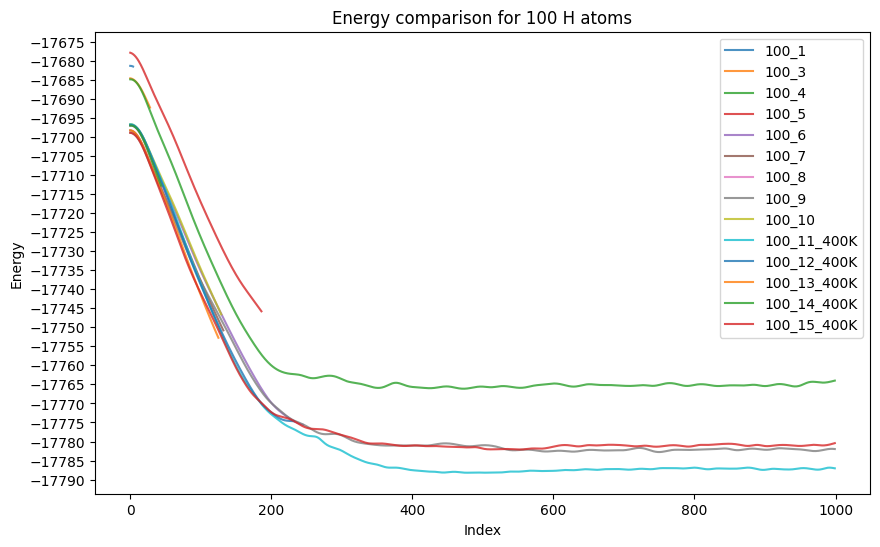

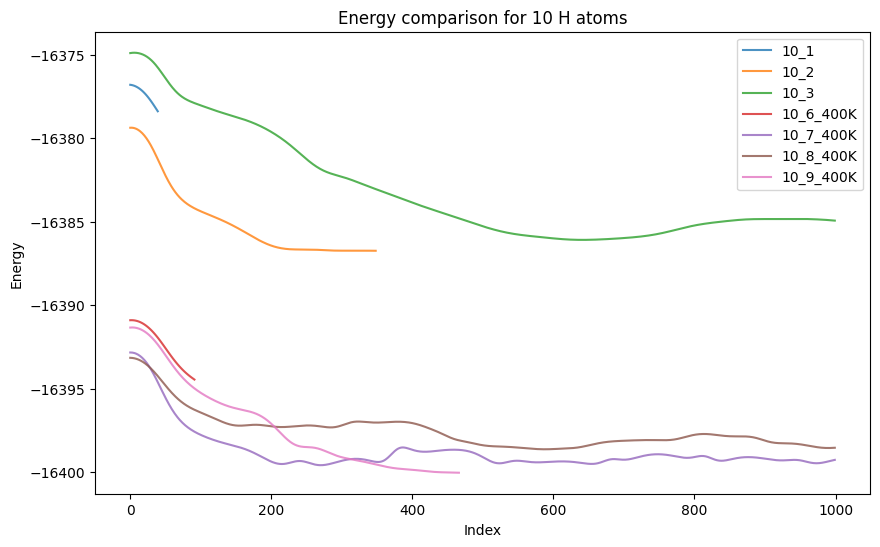

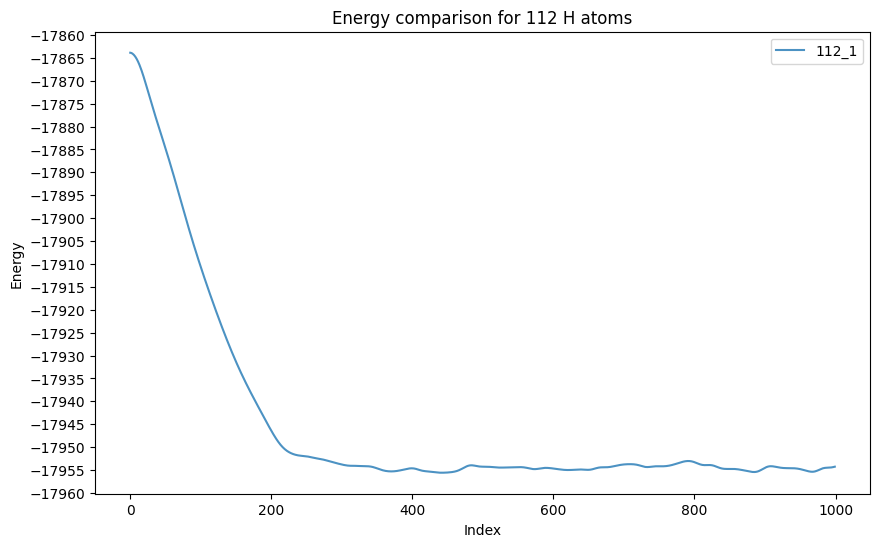

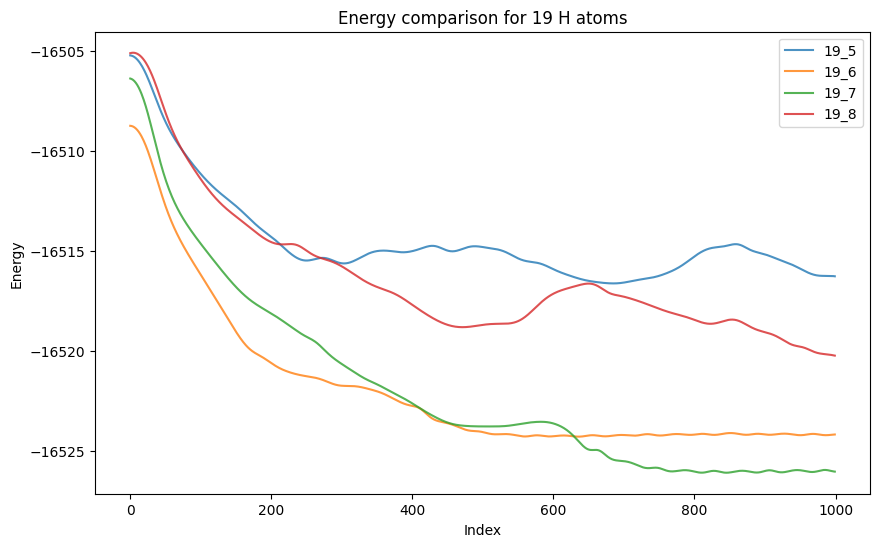

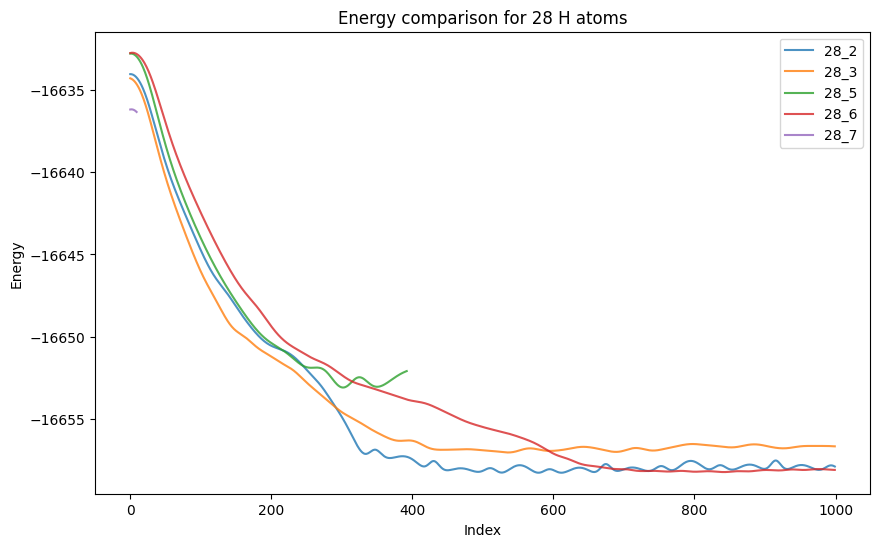

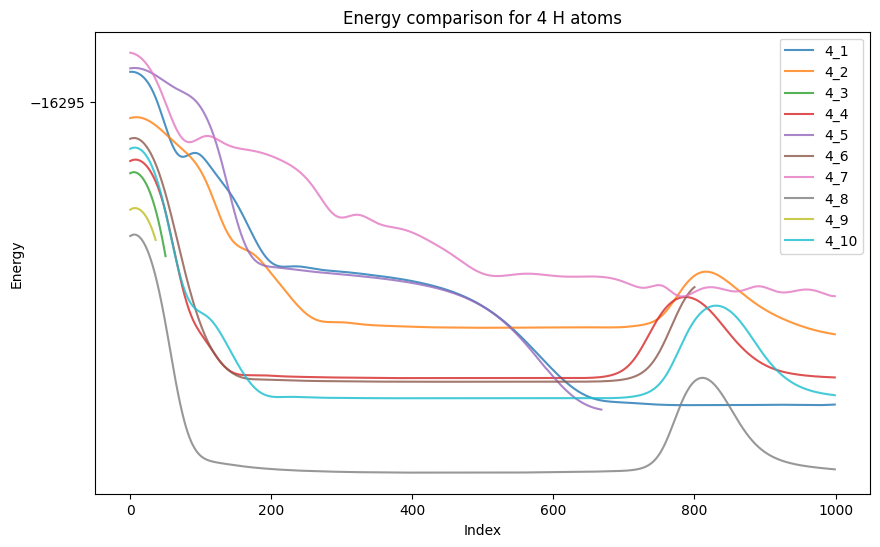

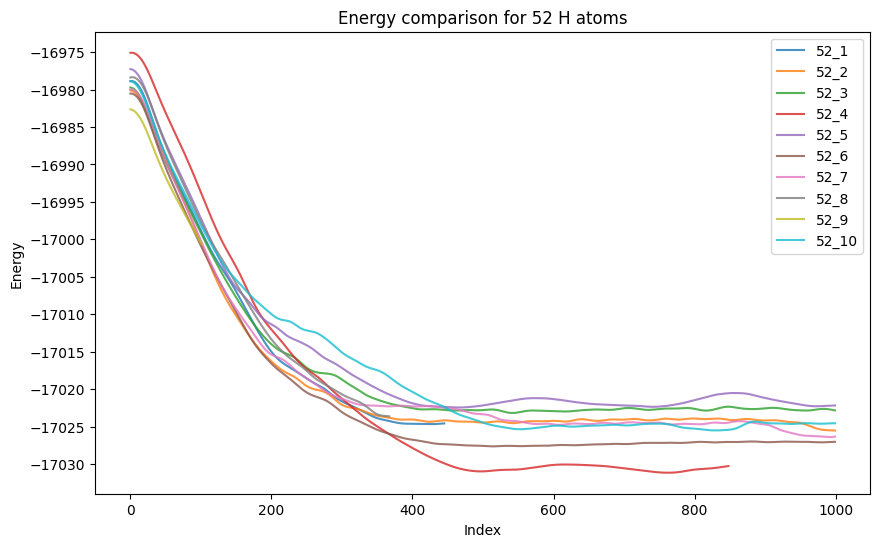

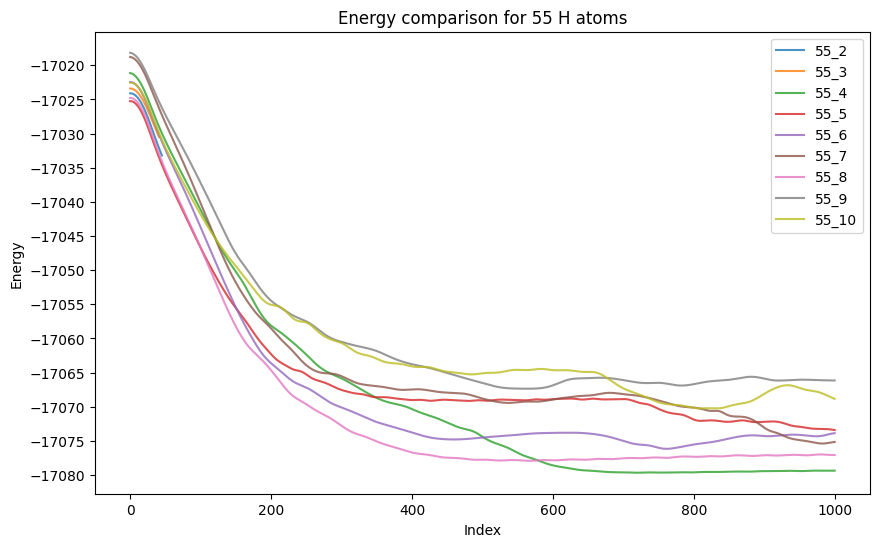

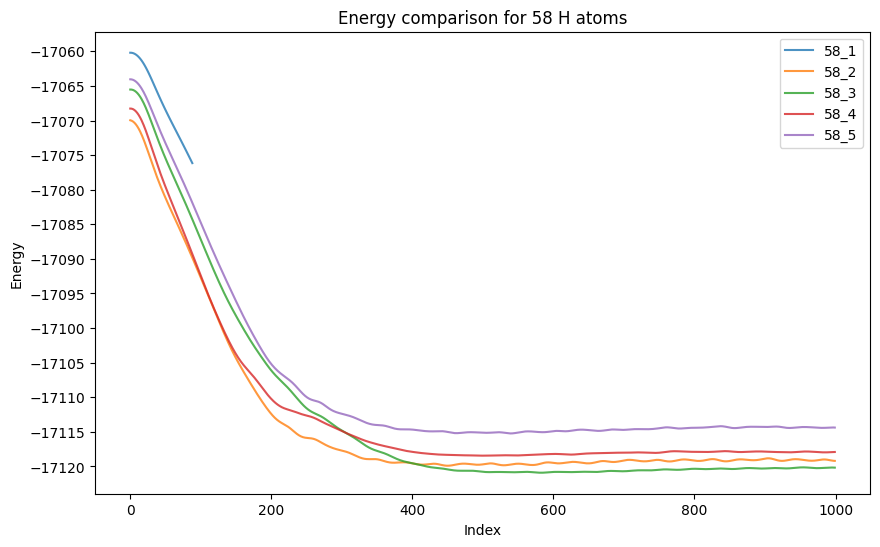

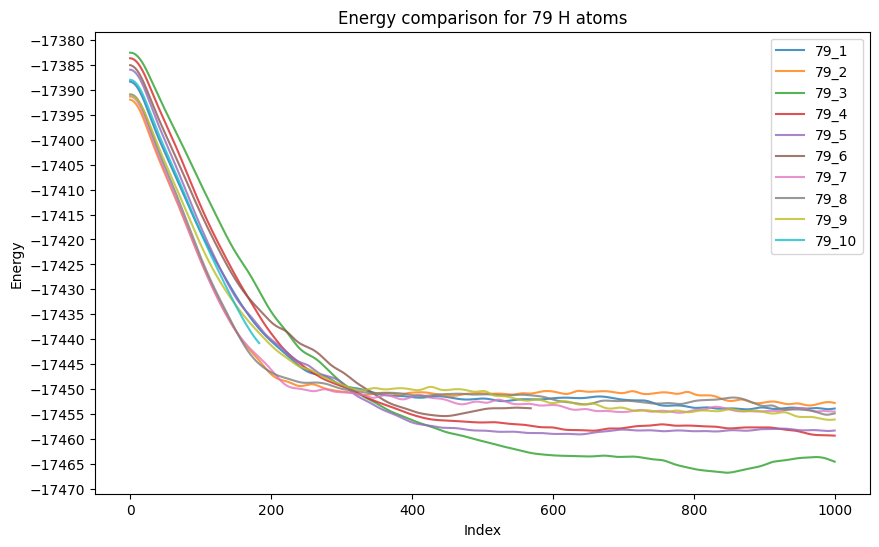

In [39]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

root = Path(r"E:\Work Spaces\Thesis\Data\SiCH_v2\input\result")

# Thu thập các đường cong năng lượng
draw = {}
for e in root.glob("prediction_data_*/set.000/energy.npy"):
    run_dir = e.parents[1].name  # "prediction_data_100_11_400K"
    if run_dir.startswith("prediction_data_"):
        key = run_dir[len("prediction_data_"):]
    else:
        # dự phòng: bỏ qua hoặc dùng nguyên tên
        # key = run_dir
        continue
    try:
        draw[key] = np.load(e)
    except Exception:
        continue

# Gom nhóm theo prefix trước dấu "_"
final = {}
for k, v in draw.items():
    idx = k.split("_", 1)[0]
    final.setdefault(idx, {})[k] = v

def natural_key(s: str):
    return [int(t) if t.isdigit() else t for t in re.split(r"(\d+)", s)]

# Vẽ
for idx, runs in final.items():
    plt.figure(figsize=(10, 6))
    for name in sorted(runs, key=natural_key):
        plt.plot(runs[name], label=name, alpha=0.8, linewidth=1.5)
    plt.xlabel("Index"); plt.ylabel("Energy")
    plt.title(f"Energy comparison for {idx} H atoms")
    plt.legend(loc="best"); plt.grid(False)
    plt.gca().yaxis.set_major_locator(MultipleLocator(5))
    plt.show()


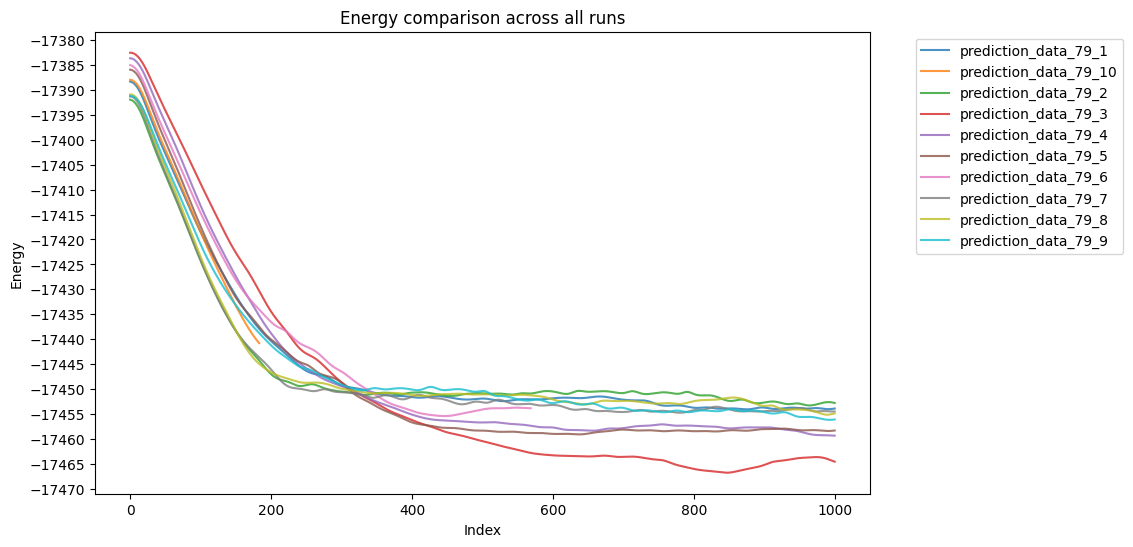

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

path = r"E:\Work Spaces\Thesis\Data\SiCH_v2\predict\result"

plt.figure(figsize=(10,6))  # create one figure

for f in os.listdir(path):
    energy = os.path.join(path, f, "set.000", "energy.npy")
    if os.path.exists(energy):
        data = np.load(energy)
        plt.plot(data, label=f, alpha=0.8, linewidth=1.5)


plt.xlabel("Index")
plt.ylabel("Energy")
plt.title("Energy comparison across all runs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(5))
plt.show()


#### Convert from output.out to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/raw", "dataset_siesta_raw")

#### Convert from output.out to npy

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/npy", "dataset_siesta_npy")

#### Convert from npy to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("training_data", fmt="deepmd/npy")
sys.to("deepmd/raw", "dataset_raw")

#### Read log to visual data distribution

Total number of frames per folder:
Folder 10: 3948 frames
Folder 100: 5189 frames
Folder 112: 1000 frames
Folder 19: 4000 frames
Folder 28: 3403 frames
Folder 4: 7558 frames
Folder 52: 7765 frames
Folder 55: 7088 frames
Folder 58: 4089 frames
Folder 79: 8753 frames


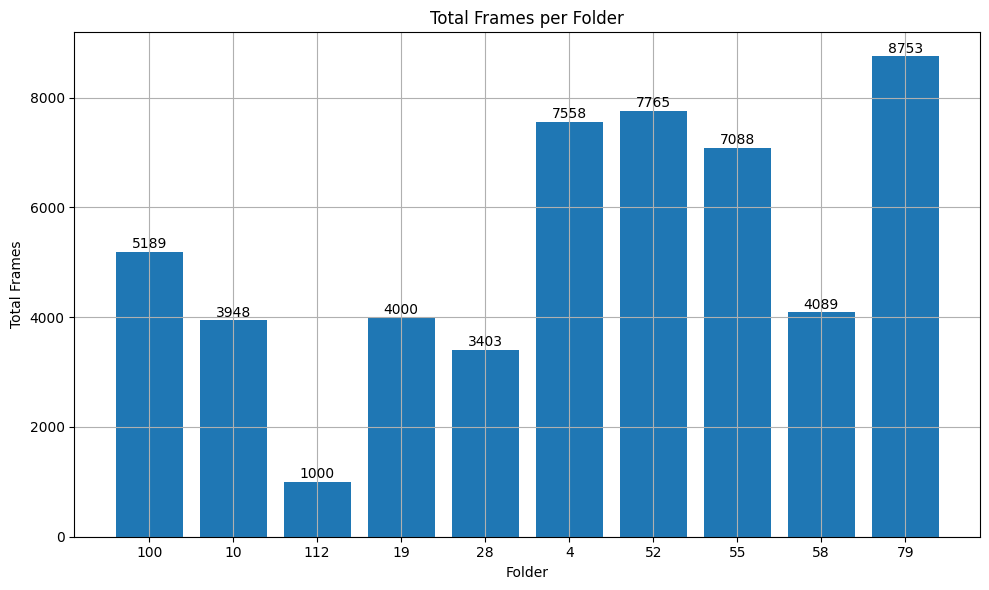

In [3]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# List of folders to be analyzed
target_folders = {'4', '10', '19', '28', '52', '55', '58', "79", '100', '112'}
frame_counts = defaultdict(int)

# Read log file
with open(r'E:\Work Spaces\Thesis\Code\ThesisMaster\logs\2025-09-12_22-18-59\log.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Iterate through each line
for i in range(len(lines) - 1):
    line = lines[i].strip()

    # Match lines that contain input folder path
    match = re.search(r"input\\(\d+)", line)
    if match:
        folder_id = match.group(1)
        if folder_id in target_folders:
            next_line = lines[i + 1].strip()
            # Check if next line contains frame information
            frame_match = re.search(r"the data contains (\d+) frames", next_line)
            if frame_match:
                num_frames = int(frame_match.group(1))
                frame_counts[folder_id] += num_frames

# Print result
print("Total number of frames per folder:")
for folder in sorted(frame_counts):
    print(f"Folder {folder}: {frame_counts[folder]} frames")

# Plot distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(frame_counts.keys(), frame_counts.values())

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10, str(height),
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Folder")
plt.ylabel("Total Frames")
plt.title("Total Frames per Folder")
plt.grid(True)
plt.tight_layout()
plt.show()
